📊 TABEL REKAP 8 EKSPERIMEN (LENGKAP DENGAN FP, FN, TOTAL ERROR)
Eksperimen  MFCC  K Akurasi Precision Recall     F1  FP  FN  Total_Error
     M1-K1    13  3  97.41%     97.9% 98.11%  98.0%  59  53          112
     M1-K2    13  5  97.11%    97.58% 97.96% 97.77%  68  57          125
     M1-K3    13  7  96.43%    96.71% 97.82% 97.26%  93  61          154
     M1-K4    13  9   96.5%    97.45% 97.14%  97.3%  71  80          151
     M2-K1    18  3  98.77%    99.07% 99.03% 99.05%  26  27           53
     M2-K2    18  5  98.66%    98.79% 99.14% 98.97%  34  24           58
     M2-K3    18  7  98.54%    98.93% 98.82% 98.87%  30  33           63
     M2-K4    18  9  98.59%    98.75% 99.07% 98.91%  35  26           61




C:\Users\Asus\AppData\Local\Temp\ipykernel_21656\630235656.py:91: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_21656\630235656.py:92: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.savefig('grafik_8_eksperimen_semua_metrik.png', dpi=300, bbox_inches='tight')
C:\Users\Asus\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


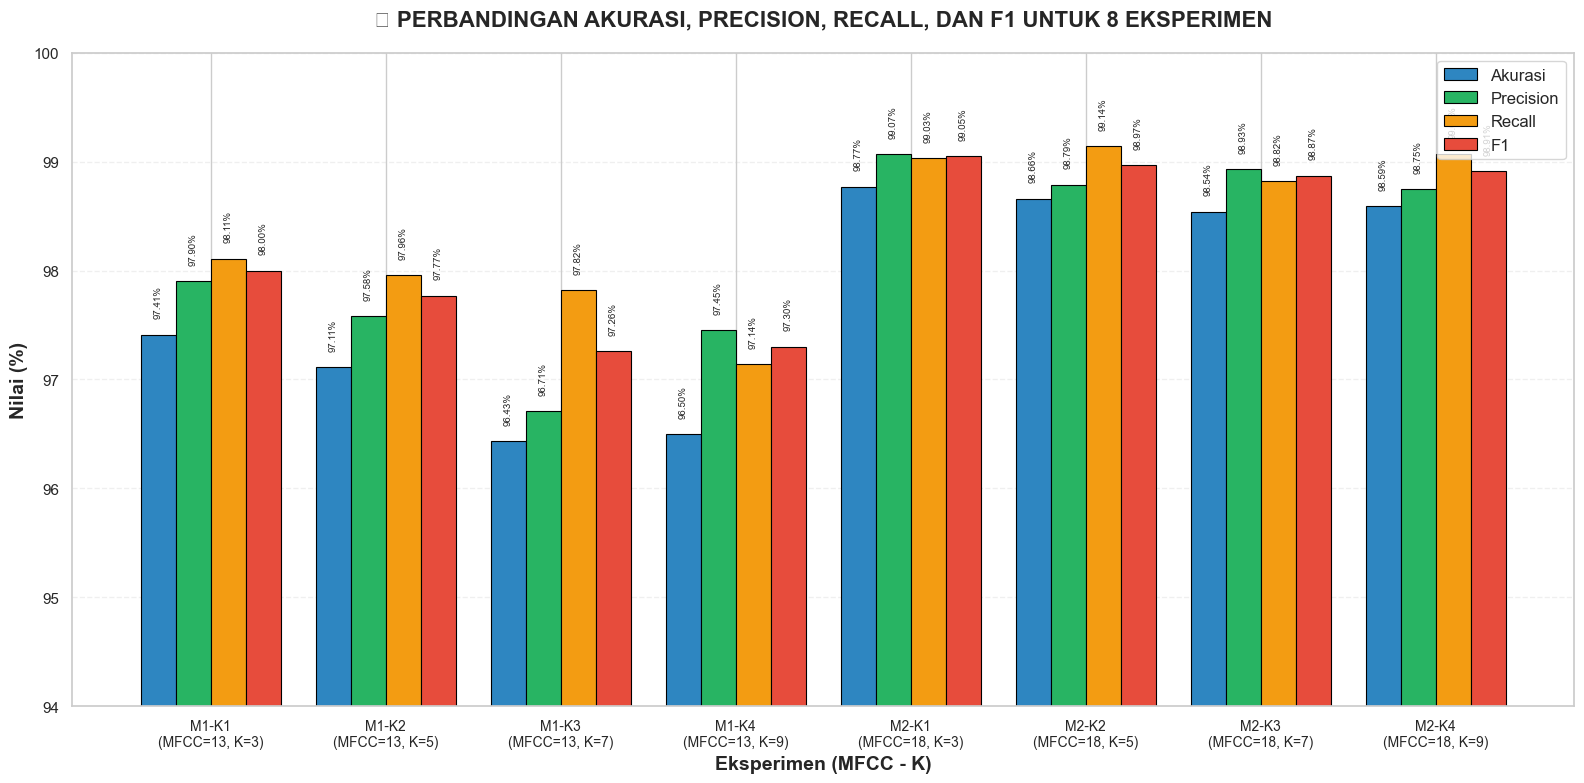

✅ Grafik berhasil disimpan: grafik_8_eksperimen_semua_metrik.png


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# DATA 8 EKSPERIMEN
# ============================================================
data = [
    # Eksperimen, MFCC, K, Akurasi, Precision, Recall, F1, CM
    ["M1-K1", 13, 3, 97.41, 97.90, 98.11, 98.00, [[1462, 59], [53, 2744]]],
    ["M1-K2", 13, 5, 97.11, 97.58, 97.96, 97.77, [[1453, 68], [57, 2740]]],
    ["M1-K3", 13, 7, 96.43, 96.71, 97.82, 97.26, [[1428, 93], [61, 2736]]],
    ["M1-K4", 13, 9, 96.50, 97.45, 97.14, 97.30, [[1450, 71], [80, 2717]]],
    ["M2-K1", 18, 3, 98.77, 99.07, 99.03, 99.05, [[1495, 26], [27, 2770]]],
    ["M2-K2", 18, 5, 98.66, 98.79, 99.14, 98.97, [[1487, 34], [24, 2773]]],
    ["M2-K3", 18, 7, 98.54, 98.93, 98.82, 98.87, [[1491, 30], [33, 2764]]],
    ["M2-K4", 18, 9, 98.59, 98.75, 99.07, 98.91, [[1486, 35], [26, 2771]]],
]

df = pd.DataFrame(data, columns=["Eksperimen", "MFCC", "K", "Akurasi", "Precision", "Recall", "F1", "CM"])

# Hitung FP (False Positive), FN (False Negative), Total Error dari CM
def hitung_error(cm):
    # cm = [[TN, FP], [FN, TP]]  -> sesuai urutan Male (baris 0) dan Female (baris 1)
    # Untuk kelas Male: FN = cm[1][0] (baris Female, kolom Male), FP = cm[0][1] (baris Male, kolom Female)
    tn, fp = cm[0][0], cm[0][1]
    fn, tp = cm[1][0], cm[1][1]
    total_salah = fp + fn
    return fp, fn, total_salah

df["FP"], df["FN"], df["Total_Error"] = zip(*df["CM"].apply(hitung_error))

# ============================================================
# 1. CETAK TABEL SUPER LENGKAP DI TERMINAL
# ============================================================
print("=" * 140)
print("📊 TABEL REKAP 8 EKSPERIMEN (LENGKAP DENGAN FP, FN, TOTAL ERROR)")
print("=" * 140)

# Format tabel
df_tampil = df[["Eksperimen", "MFCC", "K", "Akurasi", "Precision", "Recall", "F1", "FP", "FN", "Total_Error"]].copy()

# Ubah ke persen dengan 2 desimal
for col in ["Akurasi", "Precision", "Recall", "F1"]:
    df_tampil[col] = df_tampil[col].round(2).astype(str) + "%"

# Tampilkan
print(df_tampil.to_string(index=False))
print("\n")

# ============================================================
# 2. VISUALISASI: GROUPED BAR CHART (SEMUA METRIK + LABEL PARAMETER)
# ============================================================
fig, ax = plt.subplots(figsize=(16, 8))

x = np.arange(len(df["Eksperimen"]))  
width = 0.2  

metriks = ["Akurasi", "Precision", "Recall", "F1"]
warna = ['#2E86C1', '#28B463', '#F39C12', '#E74C3C']  # Biru, Hijau, Kuning, Merah

for i, metrik in enumerate(metriks):
    bars = ax.bar(x + i*width, df[metrik], width, label=metrik, 
                  color=warna[i], edgecolor='black', linewidth=0.8, zorder=2)

# Setting sumbu dan label
ax.set_xlabel('Eksperimen (MFCC - K)', fontsize=14, fontweight='bold')
ax.set_ylabel('Nilai (%)', fontsize=14, fontweight='bold')
ax.set_title('📊 PERBANDINGAN AKURASI, PRECISION, RECALL, DAN F1 UNTUK 8 EKSPERIMEN', 
             fontsize=16, fontweight='bold', pad=20)

# Set tick labels dengan parameter (MFCC=13, K=3) di bawah eksperimen
labels = [f"{row['Eksperimen']}\n(MFCC={row['MFCC']}, K={row['K']})" for _, row in df.iterrows()]
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(labels, rotation=0, ha='center', fontsize=10)

ax.legend(loc='upper right', fontsize=12)
ax.set_ylim([94, 100])
ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)

# Tambahkan label nilai di atas batang (hanya untuk yang muat)
for i, metrik in enumerate(metriks):
    for j, val in enumerate(df[metrik]):
        ax.text(j + i*width, val + 0.15, f'{val:.2f}%', 
                ha='center', va='bottom', fontsize=7, rotation=90)

# Tandai batas error (opsional: tambahkan garis horizontal untuk error terendah)
# Tidak perlu, biar fokus ke grafik

plt.tight_layout()
plt.savefig('grafik_8_eksperimen_semua_metrik.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Grafik berhasil disimpan: grafik_8_eksperimen_semua_metrik.png")

C:\Users\Asus\AppData\Local\Temp\ipykernel_21656\2262692258.py:60: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_21656\2262692258.py:61: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.savefig('grid_confusion_matrix_8_eksperimen.png', dpi=300, bbox_inches='tight')
C:\Users\Asus\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


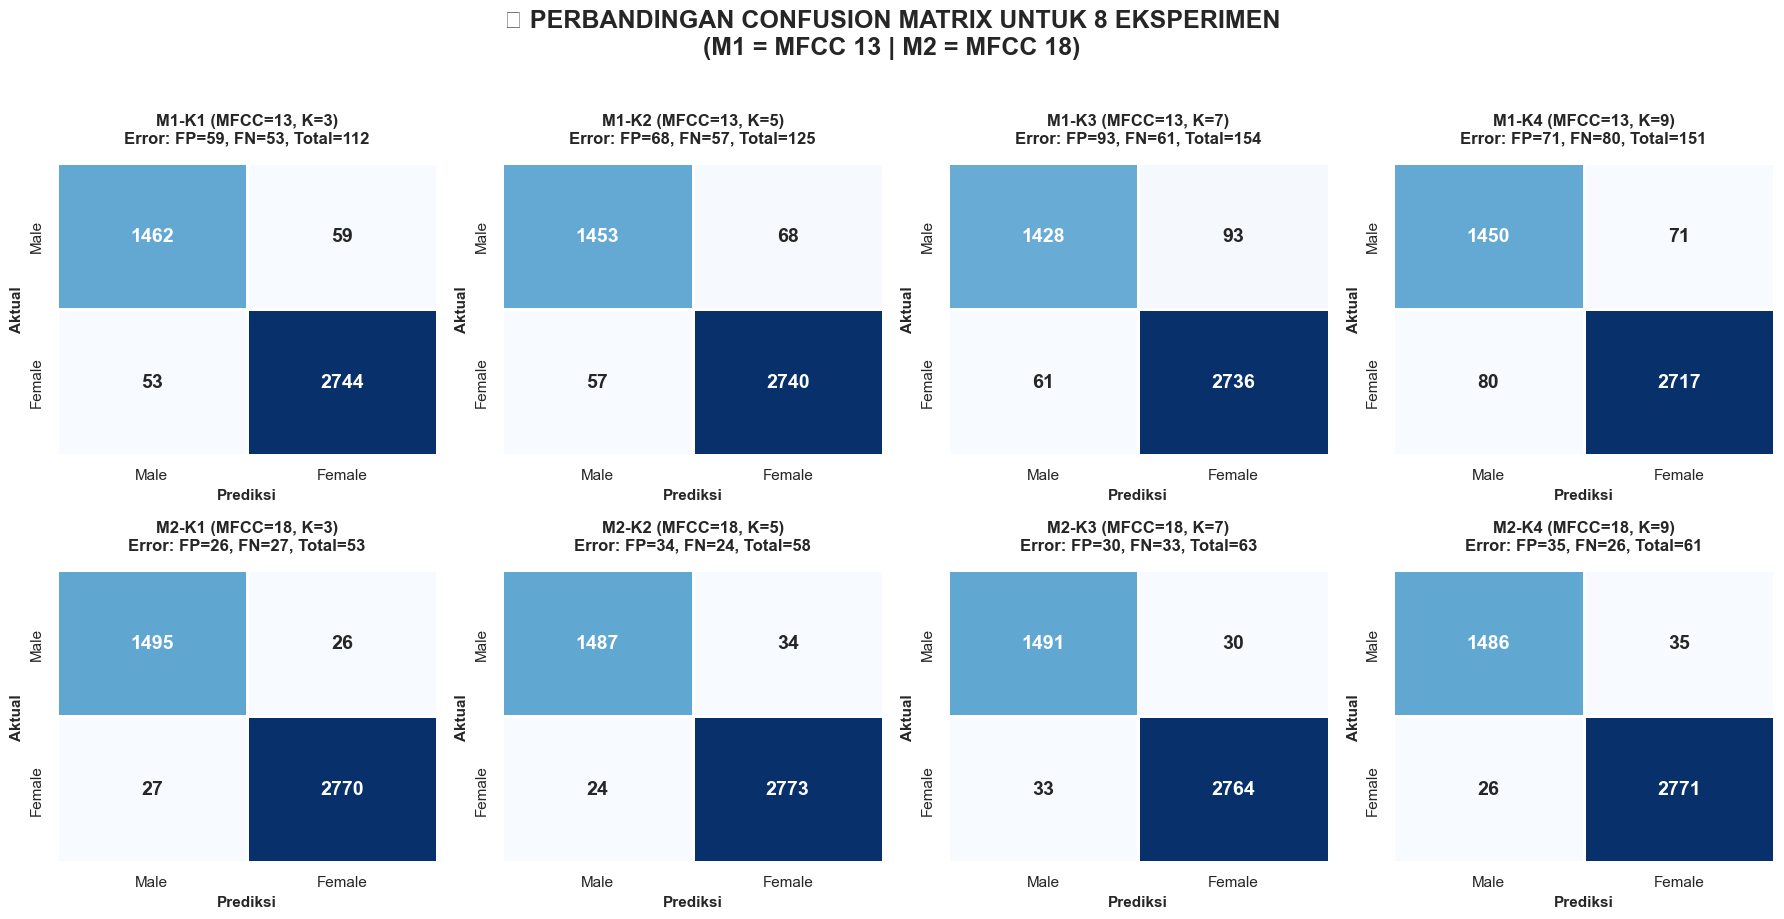

✅ Grafik Confusion Matrix berhasil disimpan: grid_confusion_matrix_8_eksperimen.png


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# DATA 8 EKSPERIMEN (Confusion Matrix)
# Urutan: M1-K1, M1-K2, M1-K3, M1-K4, M2-K1, M2-K2, M2-K3, M2-K4
# ============================================================

eksperimen_list = [
    {"nama": "M1-K1", "MFCC": 13, "K": 3, "cm": [[1462, 59], [53, 2744]]},
    {"nama": "M1-K2", "MFCC": 13, "K": 5, "cm": [[1453, 68], [57, 2740]]},
    {"nama": "M1-K3", "MFCC": 13, "K": 7, "cm": [[1428, 93], [61, 2736]]},
    {"nama": "M1-K4", "MFCC": 13, "K": 9, "cm": [[1450, 71], [80, 2717]]},
    {"nama": "M2-K1", "MFCC": 18, "K": 3, "cm": [[1495, 26], [27, 2770]]},
    {"nama": "M2-K2", "MFCC": 18, "K": 5, "cm": [[1487, 34], [24, 2773]]},
    {"nama": "M2-K3", "MFCC": 18, "K": 7, "cm": [[1491, 30], [33, 2764]]},
    {"nama": "M2-K4", "MFCC": 18, "K": 9, "cm": [[1486, 35], [26, 2771]]},
]

# ============================================================
# BUAT GRID 2 BARIS x 4 KOLOM
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()  # flatten agar mudah di-loop

labels = ['Male', 'Female']  # Label untuk sumbu

for idx, exp in enumerate(eksperimen_list):
    ax = axes[idx]
    cm = np.array(exp["cm"])
    
    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels,
                cbar=False, ax=ax, linewidths=1, linecolor='white',
                annot_kws={'size': 14, 'weight': 'bold'})
    
    # Hitung total error untuk ditampilkan di judul
    fp = cm[0][1]  # False Positive (Female terdeteksi Male)
    fn = cm[1][0]  # False Negative (Male terdeteksi Female)
    total_error = fp + fn
    
    # Set judul per subplot
    ax.set_title(
        f"{exp['nama']} (MFCC={exp['MFCC']}, K={exp['K']})\nError: FP={fp}, FN={fn}, Total={total_error}", 
        fontsize=12, fontweight='bold', pad=15
    )
    ax.set_xlabel('Prediksi', fontsize=11, fontweight='bold')
    ax.set_ylabel('Aktual', fontsize=11, fontweight='bold')
    
    # Buat angka di diagonal lebih menonjol (opsional: tidak perlu, biarkan bawaan)

# Karena totalnya 8, tidak ada subplot kosong
plt.suptitle(
    '📊 PERBANDINGAN CONFUSION MATRIX UNTUK 8 EKSPERIMEN\n(M1 = MFCC 13 | M2 = MFCC 18)', 
    fontsize=18, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('grid_confusion_matrix_8_eksperimen.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Grafik Confusion Matrix berhasil disimpan: grid_confusion_matrix_8_eksperimen.png")